# Optimised Solution

### 1. Load and clean the data

In [2]:
from pyspark.sql import SparkSession
from pyspark import StorageLevel

import csv

spark = SparkSession.builder.master("local[*]").appName("clean-us-accidents").config("spark.driver.memory", "8g").getOrCreate()
sc = spark.sparkContext

lines = sc.textFile("US_Accidents_March23.csv", minPartitions=8)
header = lines.first()

def parse_csv_line(line: str):
    return next(csv.reader([line]))

header_cols = parse_csv_line(header)
rows_rdd = (
    lines.filter(lambda x: x != header)
         .map(parse_csv_line)
         .map(lambda vals: dict(zip(header_cols, vals)))
).persist(StorageLevel.MEMORY_AND_DISK)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/21 22:12:19 WARN Utils: Your hostname, Franks-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.153 instead (on interface en9)
26/03/21 22:12:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/21 22:12:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
import math
import csv
import io
from typing import Dict, Any, Optional, List, Iterable, Tuple
from pyspark import RDD

US_STATES = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA",
    "ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK",
    "OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"
}

WEATHER_BOUNDS = {
    "Temperature(F)": (-70.0, 130.0),
    "Wind_Chill(F)": (-50.0, 130.0),
    "Humidity(%)": (0.0, 100.0),
    "Pressure(in)": (15.0, 32.0),
    "Visibility(mi)": (0.0, 100.0),
    "Wind_Speed(mph)": (0.0, 200.0),
    "Precipitation(in)": (0.0, 50.0),
}

COLS_TO_DROP = {"ID", "Source", "Zipcode", "Timezone", "Airport_Code", "End_Lat", "End_Lng"}

WIND_DIR_MAP = {
    "VARIABLE": "VAR",
    "VAR": "VAR",
    "CALM": "CALM",
    "NORTH": "N",
    "SOUTH": "S",
    "EAST": "E",
    "WEST": "W"
}

TWILIGHT_COLS = (
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
)

BOOL_COLS = (
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
)

def _safe_float(x: Any) -> Optional[float]:
    try:
        if x is None:
            return None
        if isinstance(x, str):
            x = x.strip()
            if x == "":
                return None
        val = float(x)
        if math.isnan(val):
            return None
        return val
    except (TypeError, ValueError):
        return None

def _safe_int_from_float(x: Any) -> Optional[int]:
    if x is None:
        return None
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return None
    return int(round(float(x)))

# Assume missing boolean values to be false
def _normalize_bool(v: Any) -> bool:
    if isinstance(v, bool):
        return v
    if isinstance(v, str):
        s = v.strip().lower()
        return s == "true"
    return False

def _compute_median(vals: List[float]) -> Optional[float]:
    if not vals:
        return None
    vals.sort()
    n = len(vals)
    mid = n // 2
    if n % 2 == 1:
        return float(vals[mid])
    return (vals[mid - 1] + vals[mid]) / 2.0

def _clean_row(
    row: Dict[str, Any],
    weather_cols: List[str]
) -> Optional[Dict[str, Any]]:
    row = dict(row)

    # Trim strings
    for k, v in row.items():
        if isinstance(v, str):
            row[k] = v.strip()

    # Must have Start_Time
    st = row.get("Start_Time")
    if st is None or (isinstance(st, str) and st.strip() == ""):
        return None

    # Severity in [1, 4]
    if "Severity" in row:
        sev = _safe_int_from_float(row.get("Severity"))
        if sev is None or not (1 <= sev <= 4):
            return None
        row["Severity"] = sev

    # Coordinates
    lat = _safe_float(row.get("Start_Lat"))
    if lat is None or not (-90.0 <= lat <= 90.0):
        return None
    row["Start_Lat"] = lat

    lng = _safe_float(row.get("Start_Lng"))
    if lng is None or not (-180.0 <= lng <= 180.0):
        return None
    row["Start_Lng"] = lng

    # State
    if "State" in row:
        state = row.get("State")
        if isinstance(state, str) and state.strip():
            state = state.upper()
            row["State"] = state if state in US_STATES else None
        else:
            row["State"] = None

    # Weather bounds
    for c in weather_cols:
        lo, hi = WEATHER_BOUNDS[c]
        val = _safe_float(row.get(c))
        if val is None:
            row[c] = None
        else:
            row[c] = val if lo <= val <= hi else None

    # Wind direction
    if "Wind_Direction" in row:
        wd = row.get("Wind_Direction")
        if isinstance(wd, str) and wd.strip():
            wd_up = wd.upper()
            row["Wind_Direction"] = WIND_DIR_MAP.get(wd_up, wd_up)
        else:
            row["Wind_Direction"] = None

    # Twilight columns
    for c in TWILIGHT_COLS:
        if c in row:
            val = row.get(c)
            if isinstance(val, str) and val.strip():
                val_t = val.title()
                row[c] = val_t if val_t in ("Day", "Night") else "Unknown"
            else:
                row[c] = "Unknown"

    # Boolean columns
    for c in BOOL_COLS:
        if c in row:
            row[c] = _normalize_bool(row.get(c))

    # Drop redundant columns
    for c in COLS_TO_DROP:
        row.pop(c, None)

    return row

def clean_us_accidents_pyspark(
    rows: RDD[Dict[str, Any]],
    header_cols: List[str],
    output_dir: str,
    sample_fraction_for_median: float = 0.01,
    max_sample_rows: int = 50000,
) -> None:
    sc = rows.context
    weather_cols = [c for c in WEATHER_BOUNDS if c in header_cols]
    output_cols = [c for c in header_cols if c not in COLS_TO_DROP]

    def key_by_id(iterator: Iterable[Dict[str, Any]]) -> Iterable[Tuple[str, Dict[str, Any]]]:
        for row in iterator:
            rid = str(row.get("ID", "") or "").strip()
            if rid:
                yield (rid, row)

    deduped_rows = (
        rows
        .mapPartitions(key_by_id)
        .reduceByKey(lambda a, b: a)
        .values()
    )

    def clean_partition(iterator: Iterable[Dict[str, Any]]) -> Iterable[Dict[str, Any]]:
        local_weather_cols = weather_cols
        for row in iterator:
            cleaned = _clean_row(row, local_weather_cols)
            if cleaned is not None:
                yield cleaned

    cleaned = deduped_rows.mapPartitions(clean_partition)

    medians: Dict[str, Optional[float]] = {}

    if weather_cols:
        # Compute median using a sample of the data
        sampled_weather_rows = (
            cleaned
            .sample(False, sample_fraction_for_median, seed=1)
            .map(lambda r: tuple(r.get(c) for c in weather_cols))
            .take(max_sample_rows)
        )

        for i, c in enumerate(weather_cols):
            vals = []
            for row_vals in sampled_weather_rows:
                v = row_vals[i]
                if v is not None and not math.isnan(v):
                    vals.append(float(v))
            medians[c] = _compute_median(vals)

    medians_bc = sc.broadcast(medians)

    # Write to csv
    def fill_and_dump(partition_index: int, iterator: Iterable[Dict[str, Any]]) -> Iterable[str]:
        local_medians = medians_bc.value
        local_weather_cols = weather_cols
        local_output_cols = output_cols

        sio = io.StringIO()
        writer = csv.DictWriter(sio, fieldnames=local_output_cols, extrasaction='ignore', lineterminator='')

        if partition_index == 0:
            writer.writeheader()
            header_str = sio.getvalue()
            yield header_str
            sio.seek(0)
            sio.truncate(0)

        for r in iterator:
            for c in local_weather_cols:
                if r.get(c) is None and local_medians.get(c) is not None:
                    r[c] = float(local_medians[c])
            
            writer.writerow(r)
            row_str = sio.getvalue()
            yield row_str
            
            sio.seek(0)
            sio.truncate(0)
    final_rdd = cleaned.mapPartitionsWithIndex(fill_and_dump)
    
    final_rdd.saveAsTextFile(output_dir)

In [4]:
import os
import glob
import shutil

# Please change the output dir/file accordingly
output_dir = "out/cleaned_csv"
output_file = "pyspark_cleaned_accidents.csv"

# Output will be in different parts, merge_spark_output will merge all the files into 1 single csv file
clean_us_accidents_pyspark(
    rows=rows_rdd,
    header_cols=header_cols,
    output_dir=output_dir,
)

def merge_spark_output(spark_dir: str, final_filename: str):
    # Find all part files in the output directory
    part_files = sorted(glob.glob(os.path.join(spark_dir, "part-*")))
    
    with open(final_filename, 'wb') as outfile:
        for i, fname in enumerate(part_files):
            with open(fname, 'rb') as infile:
                shutil.copyfileobj(infile, outfile)
    
merge_spark_output(output_dir, output_file)

In [6]:
spark.stop()

### 2. Analysis of Time of the accident

In [ ]:
# TODO

In [ ]:
spark.stop()

### 3. Analysis of Points of Interest at location of Accident

In [ ]:
# TODO

In [ ]:
spark.stop()

### 4. Weather Analysis

In [7]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Weather Analysis RDD") \
    .master("local[*]") \
    .getOrCreate()
sc = spark.sparkContext
raw_rdd = sc.textFile("pyspark_cleaned_accidents.csv")
header = raw_rdd.first()
data_rdd = raw_rdd.filter(lambda line: line != header)
parsed_rdd = data_rdd.map(lambda line: line.split(","))

In [8]:
import matplotlib.pyplot as plt

header_list = header.split(",")

def get_column_processor(idx):
    def process_partition(iterator):
        for row in iterator:
            try:
                val = row[idx]
                if val and val.strip():
                    yield float(val)
            except (ValueError, IndexError):
                continue
    return process_partition

In [9]:
def plot_histogram(col):
    col_idx = header_list.index(col)
    col_rdd = parsed_rdd.mapPartitions(get_column_processor(col_idx))

    num_bins = 30
    min_col = col_rdd.min()
    max_col = col_rdd.max()
    width = (max_col - min_col) / num_bins

    def assign_to_bin(value):
        bin_idx = int((value - min_col) / width)
        if bin_idx >= num_bins:
            bin_idx = num_bins - 1
        return (bin_idx, 1)

    bin_counts_rdd = col_rdd.map(assign_to_bin) \
                            .reduceByKey(lambda a, b: a + b) \
                            .sortByKey() \
                            .collect()

    results_dict = dict(bin_counts_rdd)
    final_counts = [results_dict.get(i, 0) for i in range(num_bins)]
    final_edges = [min_col + (i * width) for i in range(num_bins)]
    plt.figure(figsize=(8, 5))
    plt.bar(
        final_edges,
        final_counts,
        width=width,
        align='edge'
    )
    plt.xlabel(col)
    plt.ylabel('Number of Accidents')
    plt.title(f'Distribution of Accidents by {col}')
    plt.tight_layout()
    plt.show()

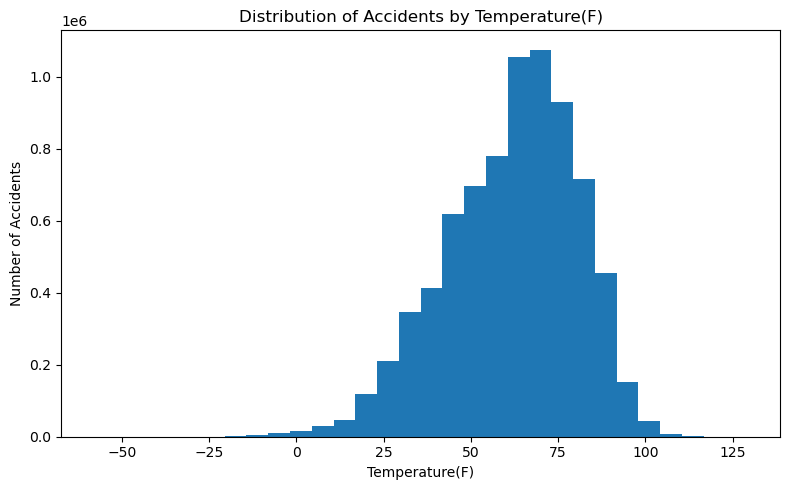

In [10]:
plot_histogram("Temperature(F)")

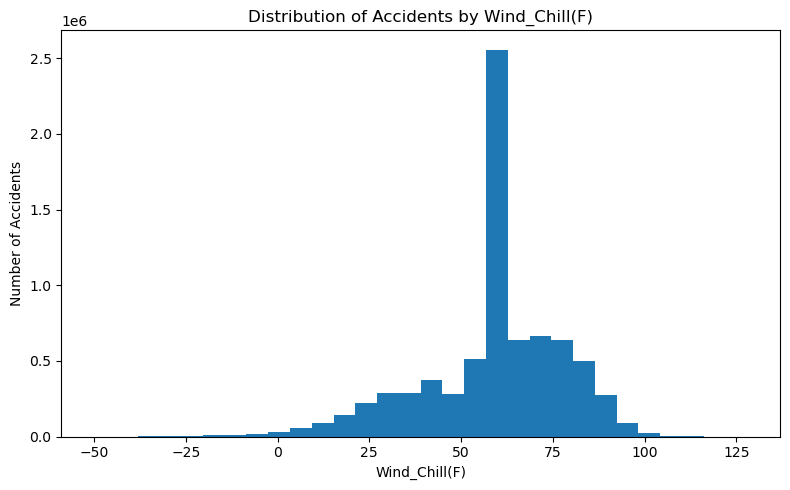

In [11]:
plot_histogram("Wind_Chill(F)")

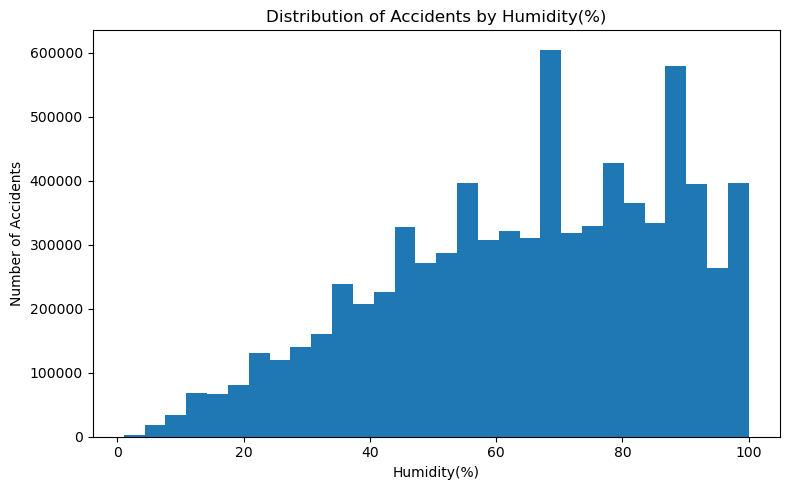

In [12]:
plot_histogram("Humidity(%)")

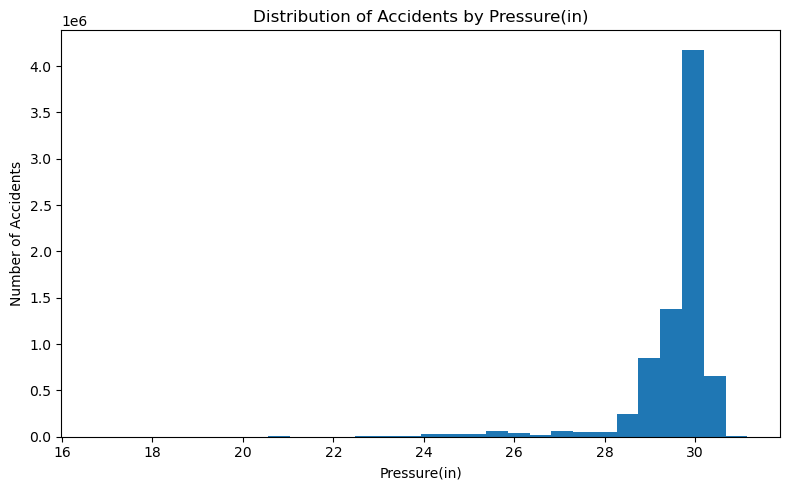

In [13]:
plot_histogram("Pressure(in)")

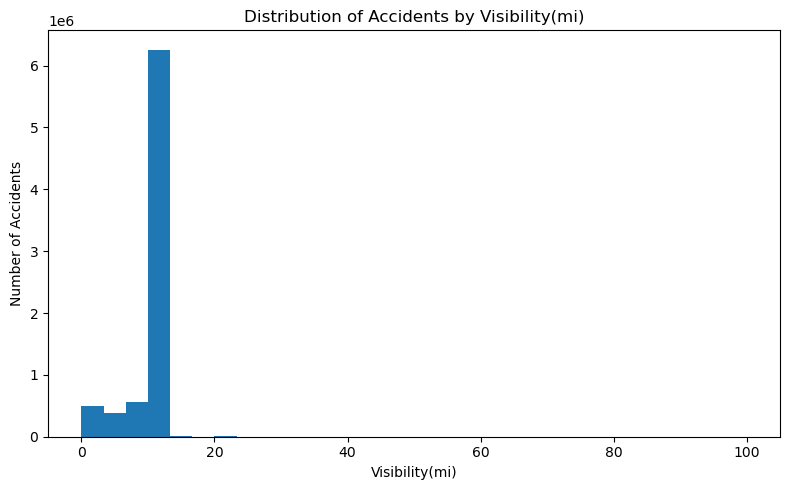

In [14]:
plot_histogram("Visibility(mi)")

In [ ]:
wind_dir_idx = header_list.index("Wind_Direction")

def get_wind_dir(iterator):
    for row in iterator:
        try:
            val = row[wind_dir_idx]
            if val and val.strip():
                yield (val.strip(), 1)
        except (IndexError, AttributeError):
            continue

wind_direction_counts = (
    parsed_rdd
    .mapPartitions(get_wind_dir)
    .reduceByKey(lambda a, b: a + b)
)

sorted_results = (
    wind_direction_counts
    .sortBy(lambda x: x[1], ascending=True)
    .collect()
)

# Unpack the list of tuples [('South', 500), ('North', 700), ...]
labels, counts = zip(*sorted_results)
plt.figure(figsize=(10, 8))
plt.barh(labels, counts)
plt.title('Wind Direction Distribution', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Wind Direction', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
plot_histogram("Wind_Speed(mph)")

In [ ]:
plot_histogram("Precipitation(in)")

In [ ]:
detailed_categories = {
    'Rainy': ['rain', 'rainy', 'drizzle', 'shower', 'raining', 'rainfall', 'precipitation'],
    'Cloudy': ['cloud', 'cloudy', 'overcast', 'mostly cloudy', 'partly cloudy'],
    'Clear': ['clear', 'sunny', 'fair'],
    'Snowy': ['snow', 'snowy', 'blizzard', 'sleet', 'ice', 'wintry', 'hail'],
    'Foggy': ['fog', 'foggy', 'mist', 'haze', 'smoke', 'dust', 'ash', 'sand'],
    'Windy': ['wind', 'windy', 'breezy'],
    'Storm': ['storm', 'thunder', 'lightning', 'squall', 'tornado']
}

header_list = header.split(",")
weather_idx = header_list.index("Weather_Condition")

def detailed_categorize_rdd(row):
    condition = row[weather_idx]

    if condition is None or condition == '':
        return 'Unknown'

    condition_lower = str(condition).lower()
    for category, keywords in detailed_categories.items():
        if any(keyword in condition_lower for keyword in keywords):
            return category
    return 'Other'

category_pairs = parsed_rdd.map(lambda row: (detailed_categorize_rdd(row), 1))
weather_counts_rdd = category_pairs.reduceByKey(lambda a, b: a + b)
final_results = weather_counts_rdd.collect()
final_results.sort(key=lambda x: x[1])

categories = [x[0] for x in final_results]
counts = [x[1] for x in final_results]
plt.figure(figsize=(10, 8))
plt.barh(categories, counts)
plt.title('Weather Category Distribution', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Weather Category', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
severity_idx = header_list.index("Severity")

def get_severity_weather_pairs(var_name):
    var_idx = header_list.index(var_name)
    def process_partition(iterator):
        for row in iterator:
            try:
                sev = row[severity_idx]
                val = float(row[var_idx])
                yield (sev, val) # (Key, Value)
            except (ValueError, IndexError):
                continue
    return process_partition

weather_cols = ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)']
plot_data = {}

for var in weather_cols:
    grouped_rdd = parsed_rdd.mapPartitions(get_severity_weather_pairs(var)).groupByKey()

    # Calculate the 5-number summary locally for each Severity
    stats_by_severity = {}
    for severity, values in grouped_rdd.collect():
        sorted_vals = sorted(list(values))
        if not sorted_vals: continue

        n = len(sorted_vals)
        stats_by_severity[severity] = {
            'min': sorted_vals[0],
            'q1': sorted_vals[int(n * 0.25)],
            'med': sorted_vals[int(n * 0.5)],
            'q3': sorted_vals[int(n * 0.75)],
            'max': sorted_vals[-1]
        }
    plot_data[var] = stats_by_severity

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, var in zip(axes.flatten(), weather_cols):
    sev_levels = sorted(plot_data[var].keys())
    box_stats = [
        {
            "label": s, "whislo": plot_data[var][s]['min'],
            "q1": plot_data[var][s]['q1'], "med": plot_data[var][s]['med'],
            "q3": plot_data[var][s]['q3'], "whishi": plot_data[var][s]['max']
        }
        for s in sev_levels
    ]
    ax.bxp(box_stats, showfliers=False)
    ax.set_title(f'{var} by Severity')

In [ ]:
# JSON version if cannot output CSV file after cleaning

import matplotlib.pyplot as plt
import json

raw_rdd = sc.textFile("out/cleaned_jsonl")
parsed_rdd = raw_rdd.map(lambda line: json.loads(line))

def get_column_processor(col_name):
    def process_partition(iterator):
        for row in iterator:
            try:
                val = row.get(col_name)
                if val is not None:
                    yield float(val)
            except (ValueError, TypeError):
                continue
    return process_partition

def plot_histogram(col_name):
    col_rdd = parsed_rdd.mapPartitions(get_column_processor(col_name))

    num_bins = 30
    min_col = col_rdd.min()
    max_col = col_rdd.max()
    width = (max_col - min_col) / num_bins

    def assign_to_bin(value):
        bin_idx = int((value - min_col) / width)
        if bin_idx >= num_bins:
            bin_idx = num_bins - 1
        return (bin_idx, 1)

    bin_counts = col_rdd.map(assign_to_bin) \
                        .reduceByKey(lambda a, b: a + b) \
                        .collectAsMap() # collectAsMap is cleaner than dict(collect)

    final_counts = [bin_counts.get(i, 0) for i in range(num_bins)]
    final_edges = [min_col + (i * width) for i in range(num_bins)]

    # Plotting logic
    plt.figure(figsize=(8, 5))
    plt.bar(final_edges, final_counts, width=width, align='edge', edgecolor='black')
    plt.xlabel(col_name)
    plt.ylabel('Number of Accidents')
    plt.title(f'Distribution of Accidents by {col_name}')
    plt.tight_layout()
    plt.show()

plot_histogram("Temperature(F)")

In [ ]:
spark.stop()

### 5. Create a Map Distribution of the locations for each Accident

In [ ]:
# TODO